# Flight Fare Prediction using Machine Learning 
# Goal: To predict flight ticket prices based on features like airline, source, destination, and stops.

## Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel(r"C:\Users\Admin\OneDrive\Desktop\ML\ML Live Flight Fare Resourses16963295320.xlsx")
data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [3]:
data.info() # information about data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
data.describe() # description of data

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [5]:
data.isnull().sum() # check null values in data

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

## Data Cleaning & EDA

In [6]:
data.drop(["Route","Additional_Info"],axis=1,inplace=True) # columns drop because this not involve in prediction and may be make bad accuracy

In [7]:
data[data["Total_Stops"].isnull()==True]

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
9039,Air India,6/05/2019,Delhi,Cochin,09:45,09:25 07 May,23h 40m,NaN,7480


In [8]:
data.dropna(inplace=True) # drop null values

In [9]:
data.isnull().any()

Airline            False
Date_of_Journey    False
Source             False
Destination        False
Dep_Time           False
Arrival_Time       False
Duration           False
Total_Stops        False
Price              False
dtype: bool

In [10]:
data["Date_of_Journey"]

0        24/03/2019
1         1/05/2019
2         9/06/2019
3        12/05/2019
4        01/03/2019
            ...    
10678     9/04/2019
10679    27/04/2019
10680    27/04/2019
10681    01/03/2019
10682     9/05/2019
Name: Date_of_Journey, Length: 10682, dtype: object

In [11]:
data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"]) # Correct date format

C:\Users\Admin\AppData\Local\Temp\ipykernel_9816\2407196714.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"]) # Correct date format


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Dep_Time         10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  object        
 8   Price            10682 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 834.5+ KB


In [13]:
import warnings
warnings.filterwarnings("ignore")

### Extract only month and day instead of whole date to improve accuracy

In [14]:
data["Journey_month"] = pd.to_datetime(data["Date_of_Journey"]).dt.month

In [15]:
data["Journey_day"] = pd.to_datetime(data["Date_of_Journey"]).dt.day

In [16]:
data.drop("Date_of_Journey",axis=1,inplace=True)

In [17]:
data.head()

,Airline,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_month,Journey_day
0,IndiGo,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,non-stop,3897,3,24
1,Air India,Kolkata,Banglore,05:50,13:15,7h 25m,2 stops,7662,5,1
2,Jet Airways,Delhi,Cochin,09:25,04:25 10 Jun,19h,2 stops,13882,6,9
3,IndiGo,Kolkata,Banglore,18:05,23:30,5h 25m,1 stop,6218,5,12
4,IndiGo,Banglore,New Delhi,16:50,21:35,4h 45m,1 stop,13302,3,1


### Extract only hour and minute instead of dep_time to improve accuracy

In [18]:
data["dep_hr"] = pd.to_datetime(data["Dep_Time"]).dt.hour

In [19]:
data["dep_min"] = pd.to_datetime(data["Dep_Time"]).dt.minute

In [20]:
data.drop("Dep_Time",axis=1,inplace=True)

In [21]:
data.head()

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,non-stop,3897,3,24,22,20
1,Air India,Kolkata,Banglore,13:15,7h 25m,2 stops,7662,5,1,5,50
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2 stops,13882,6,9,9,25
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1 stop,6218,5,12,18,5
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1 stop,13302,3,1,16,50


### Extract only hour and minute instead of arrival_time to improve accuracy

In [22]:
data["Arrival_hr"] = pd.to_datetime(data["Arrival_Time"]).dt.hour

In [23]:
data["Arrival_min"] = pd.to_datetime(data["Arrival_Time"]).dt.minute

In [24]:
data.drop("Arrival_Time",axis=1,inplace=True)

In [25]:
data.head()

,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min
0,IndiGo,Banglore,New Delhi,2h 50m,non-stop,3897,3,24,22,20,1,10
1,Air India,Kolkata,Banglore,7h 25m,2 stops,7662,5,1,5,50,13,15
2,Jet Airways,Delhi,Cochin,19h,2 stops,13882,6,9,9,25,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1 stop,6218,5,12,18,5,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1 stop,13302,3,1,16,50,21,35


## Feature Engineering

#### Airline column encoding

In [26]:
data.groupby("Airline")["Price"].mean()

Airline
Air Asia                              5590.260188
Air India                             9612.427756
GoAir                                 5861.056701
IndiGo                                5673.682903
Jet Airways                          11643.923357
Jet Airways Business                 58358.666667
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
SpiceJet                              4338.284841
Trujet                                4140.000000
Vistara                               7796.348643
Vistara Premium economy               8962.333333
Name: Price, dtype: float64

<Axes: xlabel='Airline'>

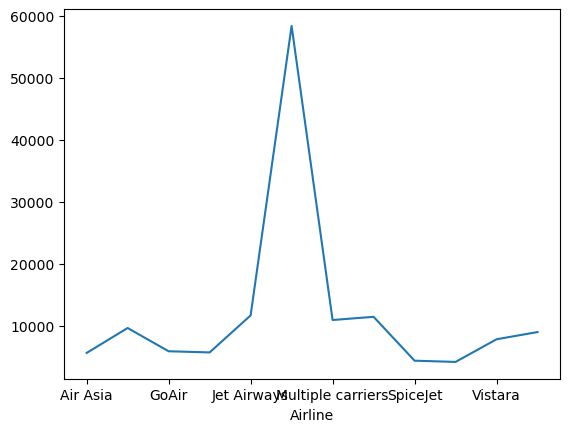

In [27]:
data.groupby("Airline")["Price"].mean().plot()

In [28]:
airline = pd.get_dummies(data["Airline"])
airline

,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,False,True,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,True,False,False,False,False,False,False,False,False,False,False,False
10679,False,True,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,True,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,True,False


#### Source column encoding

<Axes: xlabel='Source'>

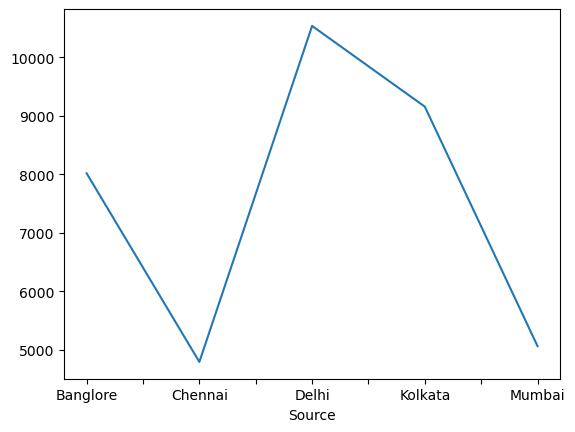

In [29]:
data.groupby("Source")["Price"].mean().plot()

In [30]:
source = pd.get_dummies(data["Source"])
source

,Banglore,Chennai,Delhi,Kolkata,Mumbai
0,True,False,False,False,False
1,False,False,False,True,False
2,False,False,True,False,False
3,False,False,False,True,False
4,True,False,False,False,False
...,...,...,...,...,...
10678,False,False,False,True,False
10679,False,False,False,True,False
10680,True,False,False,False,False
10681,True,False,False,False,False


#### Destination column encoding

<Axes: xlabel='Destination'>

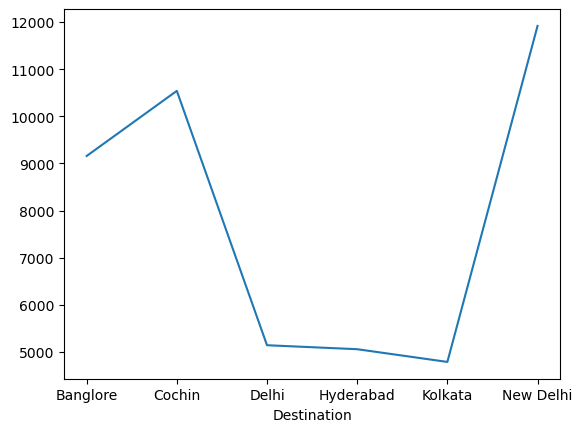

In [31]:
data.groupby("Destination")["Price"].mean().plot()

In [32]:
destination = pd.get_dummies(data["Destination"])
destination

,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,False,True
1,True,False,False,False,False,False
2,False,True,False,False,False,False
3,True,False,False,False,False,False
4,False,False,False,False,False,True
...,...,...,...,...,...,...
10678,True,False,False,False,False,False
10679,True,False,False,False,False,False
10680,False,False,True,False,False,False
10681,False,False,False,False,False,True


In [33]:
data = pd.concat([data,airline,source,destination],axis=1) # merge this into data 

In [34]:
data.drop(["Airline","Source","Destination"],axis=1,inplace=True) # drop columns afyer apply encoding

In [35]:
data.head()

,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,...,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,2h 50m,non-stop,3897,3,24,22,20,1,10,False,...,False,False,False,False,False,False,False,False,False,True
1,7h 25m,2 stops,7662,5,1,5,50,13,15,False,...,False,False,True,False,True,False,False,False,False,False
2,19h,2 stops,13882,6,9,9,25,4,25,False,...,False,True,False,False,False,True,False,False,False,False
3,5h 25m,1 stop,6218,5,12,18,5,23,30,False,...,False,False,True,False,True,False,False,False,False,False
4,4h 45m,1 stop,13302,3,1,16,50,21,35,False,...,False,False,False,False,False,False,False,False,False,True


#### Total_Stops column encoding

In [36]:
data["Total_Stops"] = data["Total_Stops"].replace(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],[0,2,1,3,4])

In [37]:
data.head()

,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,...,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,2h 50m,0,3897,3,24,22,20,1,10,False,...,False,False,False,False,False,False,False,False,False,True
1,7h 25m,2,7662,5,1,5,50,13,15,False,...,False,False,True,False,True,False,False,False,False,False
2,19h,2,13882,6,9,9,25,4,25,False,...,False,True,False,False,False,True,False,False,False,False
3,5h 25m,1,6218,5,12,18,5,23,30,False,...,False,False,True,False,True,False,False,False,False,False
4,4h 45m,1,13302,3,1,16,50,21,35,False,...,False,False,False,False,False,False,False,False,False,True


In [38]:
pd.set_option("display.max_column",None) # display all columns

In [39]:
data.head(3)

,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,2h 50m,0,3897,3,24,22,20,1,10,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True
1,7h 25m,2,7662,5,1,5,50,13,15,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
2,19h,2,13882,6,9,9,25,4,25,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False


### Extract only hour and minute instead of Duration to improve accuracy

In [40]:
for i in data["Duration"]:
    print(i.strip())

2h 50m
7h 25m
19h
5h 25m
4h 45m
2h 25m
15h 30m
21h 5m
25h 30m
7h 50m
13h 15m
2h 35m
2h 15m
12h 10m
2h 35m
26h 35m
4h 30m
22h 35m
23h
20h 35m
5h 10m
15h 20m
2h 50m
2h 55m
13h 20m
15h 10m
5h 45m
5h 55m
2h 50m
2h 15m
2h 15m
13h 25m
2h 50m
22h
5h 30m
10h 25m
5h 15m
2h 30m
6h 15m
11h 55m
11h 5m
8h 30m
22h 5m
2h 45m
12h
2h 50m
2h 50m
2h 15m
16h 5m
19h 55m
3h 15m
25h 20m
2h 50m
3h
2h 50m
16h 15m
15h 5m
2h 15m
6h 30m
25h 5m
12h 25m
27h 20m
10h 15m
10h 30m
2h 15m
10h 25m
2h 50m
1h 30m
13h 20m
2h 15m
1h 25m
26h 30m
7h 20m
13h 30m
5h
2h 45m
2h 50m
1h 30m
19h 5m
2h 15m
14h 50m
2h 40m
22h 10m
9h 35m
10h
21h 20m
5h 25m
18h 45m
12h 20m
18h
9h 15m
11h 5m
17h 30m
13h 20m
2h 35m
2h 25m
2h 40m
3h
1h 25m
16h 35m
12h 20m
12h 15m
7h 30m
24h
2h 45m
8h 55m
7h 10m
14h 30m
30h 20m
19h 55m
15h
2h 55m
12h 45m
10h 10m
5h 55m
15h 25m
16h 5m
10h 10m
2h 40m
11h 55m
2h 40m
1h 25m
14h 5m
20h 15m
2h 25m
23h 10m
18h 10m
16h
2h 50m
2h 20m
8h
16h 55m
3h 10m
2h 45m
14h
23h 50m
21h 40m
21h 15m
2h 45m
10h 50m
8h
8h 15m
5h 25m

In [41]:
df = data.copy() # this is very soft calculation so backup option

In [42]:
data["Duration_hr"] = data["Duration"].str.split().str[0] # divide hours from duration

In [43]:
data["Duration_min"] = data["Duration"].str.split().str[1] # divide minutes from duration

In [44]:
data.head()

,Duration,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hr,Duration_min
0,2h 50m,0,3897,3,24,22,20,1,10,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,2h,50m
1,7h 25m,2,7662,5,1,5,50,13,15,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,7h,25m
2,19h,2,13882,6,9,9,25,4,25,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,19h,NaN
3,5h 25m,1,6218,5,12,18,5,23,30,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,5h,25m
4,4h 45m,1,13302,3,1,16,50,21,35,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,4h,45m


In [45]:
data["Duration_hr"].fillna(0,inplace=True) # if there are null values fill

In [46]:
data["Duration_min"].fillna(0,inplace=True) # if there are null values fill

In [47]:
data[["Duration_hr","Duration_min"]] = data[["Duration_hr","Duration_min"]].replace("[h-m]"," ",regex=True) # remove h and m from columns

In [48]:
data.drop("Duration",axis=1,inplace=True)

In [49]:
data.head(2)

,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hr,Duration_min
0,0,3897,3,24,22,20,1,10,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,2,50
1,2,7662,5,1,5,50,13,15,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,7,25


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Total_Stops                        10682 non-null  int64 
 1   Price                              10682 non-null  int64 
 2   Journey_month                      10682 non-null  int32 
 3   Journey_day                        10682 non-null  int32 
 4   dep_hr                             10682 non-null  int32 
 5   dep_min                            10682 non-null  int32 
 6   Arrival_hr                         10682 non-null  int32 
 7   Arrival_min                        10682 non-null  int32 
 8   Air Asia                           10682 non-null  bool  
 9   Air India                          10682 non-null  bool  
 10  GoAir                              10682 non-null  bool  
 11  IndiGo                             10682 non-null  bool  
 12  Jet Airwa

In [51]:
data[["Duration_hr","Duration_min"]] = data[["Duration_hr","Duration_min"]].astype("i") # this is convert in int because it is object

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Total_Stops                        10682 non-null  int64
 1   Price                              10682 non-null  int64
 2   Journey_month                      10682 non-null  int32
 3   Journey_day                        10682 non-null  int32
 4   dep_hr                             10682 non-null  int32
 5   dep_min                            10682 non-null  int32
 6   Arrival_hr                         10682 non-null  int32
 7   Arrival_min                        10682 non-null  int32
 8   Air Asia                           10682 non-null  bool 
 9   Air India                          10682 non-null  bool 
 10  GoAir                              10682 non-null  bool 
 11  IndiGo                             10682 non-null  bool 
 12  Jet Airways            

In [53]:
data.head(3)

,Total_Stops,Price,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi,Duration_hr,Duration_min
0,0,3897,3,24,22,20,1,10,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,2,50
1,2,7662,5,1,5,50,13,15,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,7,25
2,2,13882,6,9,9,25,4,25,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,19,0


In [54]:
data.columns

Index(['Total_Stops', 'Price', 'Journey_month', 'Journey_day', 'dep_hr',
       'dep_min', 'Arrival_hr', 'Arrival_min', 'Air Asia', 'Air India',
       'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Banglore', 'Chennai',
       'Delhi', 'Kolkata', 'Mumbai', 'Banglore', 'Cochin', 'Delhi',
       'Hyderabad', 'Kolkata', 'New Delhi', 'Duration_hr', 'Duration_min'],
      dtype='object')

In [55]:
data = data[['Total_Stops', 'Journey_month', 'Journey_day', 'dep_hr',
       'dep_min', 'Arrival_hr', 'Arrival_min', 'Air Asia', 'Air India',
       'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Banglore', 'Chennai',
       'Delhi', 'Kolkata', 'Mumbai', 'Banglore', 'Cochin', 'Delhi',
       'Hyderabad', 'Kolkata', 'New Delhi', 'Duration_hr', 'Duration_min', 'Price']]

In [56]:
data.head()

,Total_Stops,Journey_month,Journey_day,dep_hr,dep_min,Arrival_hr,Arrival_min,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy,Banglore,Banglore,Chennai,Delhi,Delhi,Kolkata,Kolkata,Mumbai,Banglore,Banglore,Cochin,Delhi,Delhi,Hyderabad,Kolkata,Kolkata,New Delhi,Duration_hr,Duration_min,Price
0,0,3,24,22,20,1,10,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,2,50,3897
1,2,5,1,5,50,13,15,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,7,25,7662
2,2,6,9,9,25,4,25,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,19,0,13882
3,1,5,12,18,5,23,30,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,5,25,6218
4,1,3,1,16,50,21,35,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,4,45,13302


## Model Training

#### separate target variable and features

In [57]:
x = data.drop("Price",axis=1)
y = data["Price"]

#### split data into train test split

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.7,random_state=42)

#### Train model with LinearRegression because data is continues

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
model = LinearRegression()

In [62]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model Evalution

In [63]:
from sklearn.metrics import r2_score,mean_squared_error

In [64]:
ypri = model.predict(x_test)
ypri

array([13461.7280103 ,  7642.57757233,  9555.71239368, ...,
        4770.70986313,  4836.6376071 ,  7385.91397101])

In [65]:
r2_score(y_test,ypri)*100

62.639193725573136

In [66]:
mse = mean_squared_error(y_test,ypri)
mse

7621950.657488765

In [67]:
rmse = np.sqrt(mse)
rmse

np.float64(2760.7880500843894)

## Accuracy is down not any chance improve so try with different algorithms

<Axes: >

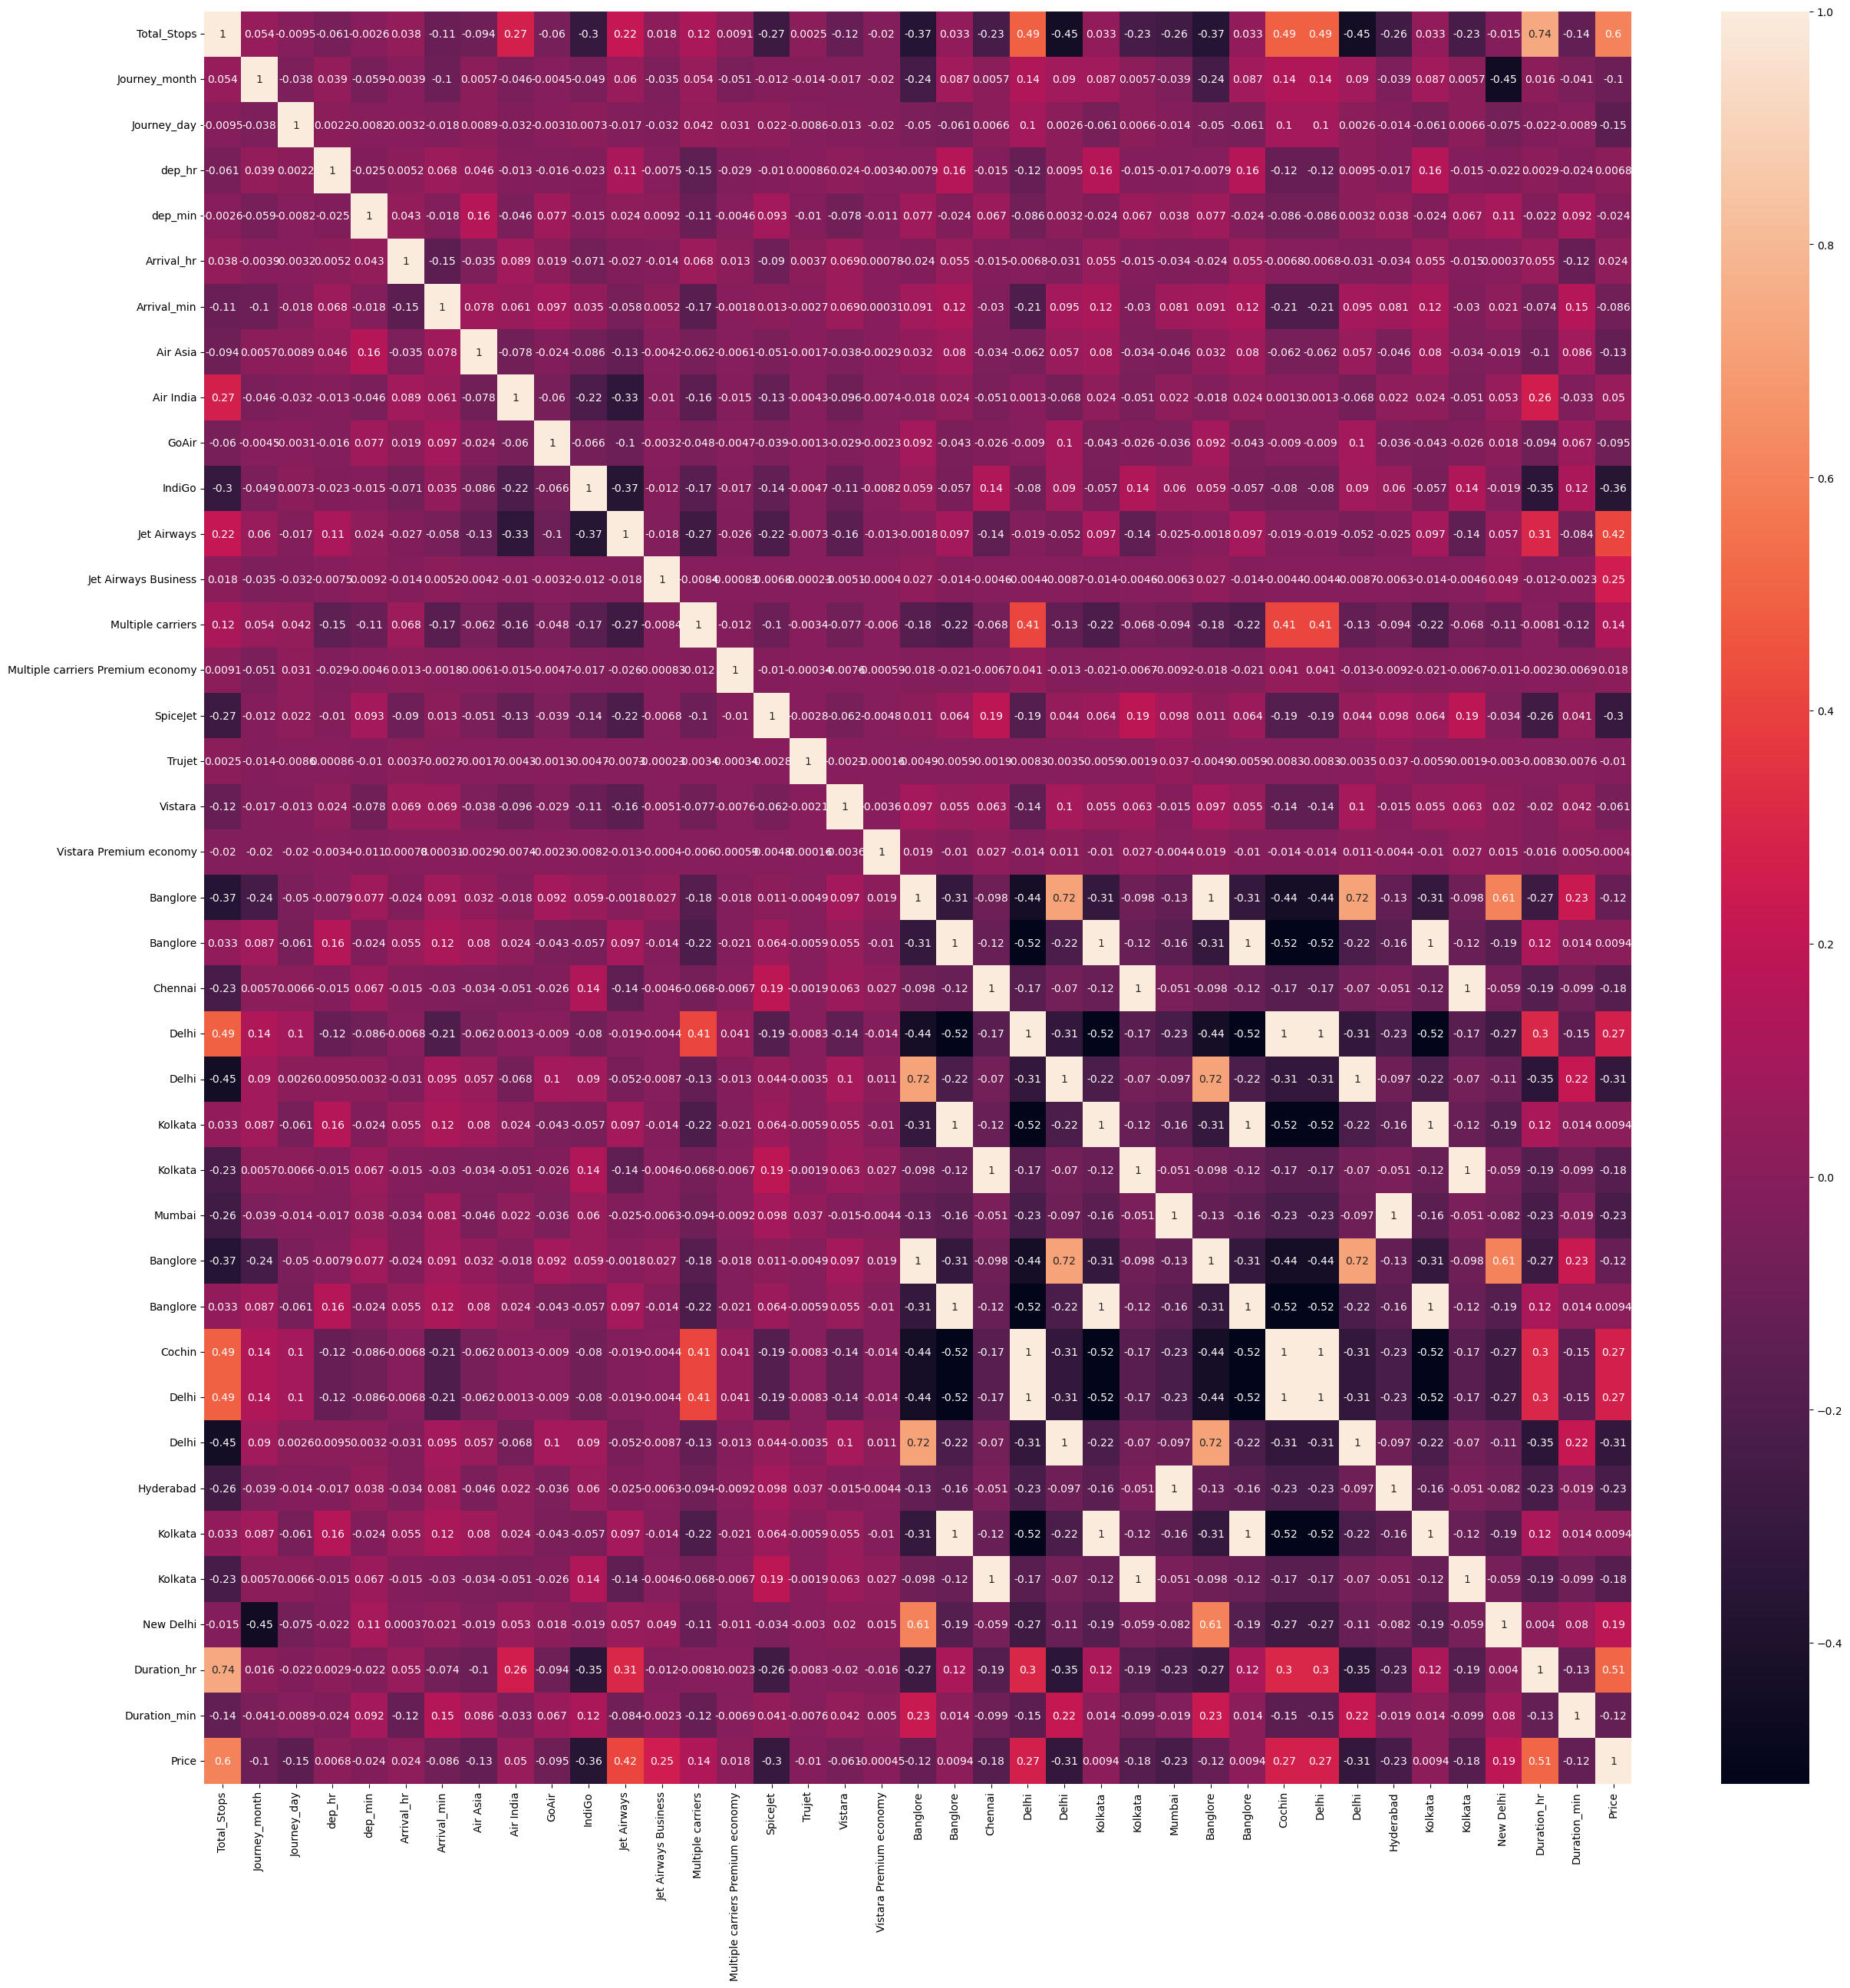

In [68]:
plt.figure(figsize=(30,30))
sns.heatmap(data.corr(),annot=True)

In [69]:
from sklearn.ensemble import ExtraTreesRegressor

In [70]:
model = ExtraTreesRegressor()

In [71]:
model.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [72]:
model.feature_importances_

array([1.98625990e-01, 5.30133183e-02, 1.44243861e-01, 2.41550803e-02,
       2.12809151e-02, 2.76043368e-02, 1.88326355e-02, 1.72973243e-03,
       8.64866079e-03, 1.70042950e-03, 1.73461663e-02, 1.32069777e-01,
       6.75325450e-02, 1.90186726e-02, 8.94326559e-04, 2.59895303e-03,
       9.18187298e-05, 4.68546996e-03, 7.89674060e-05, 5.68718077e-03,
       1.26705271e-03, 3.32298659e-04, 6.73860788e-03, 5.45660629e-03,
       1.13129095e-03, 3.10490732e-04, 6.30007312e-03, 5.35388838e-03,
       9.95565100e-04, 7.19360754e-03, 5.79667177e-03, 9.52694881e-03,
       5.78042361e-03, 1.13851942e-03, 3.76157268e-04, 1.45128217e-02,
       1.60685100e-01, 1.72650396e-02])

In [73]:
a = pd.Series(model.feature_importances_,index=x.columns)
a

Total_Stops                          0.198626
Journey_month                        0.053013
Journey_day                          0.144244
dep_hr                               0.024155
dep_min                              0.021281
Arrival_hr                           0.027604
Arrival_min                          0.018833
Air Asia                             0.001730
Air India                            0.008649
GoAir                                0.001700
IndiGo                               0.017346
Jet Airways                          0.132070
Jet Airways Business                 0.067533
Multiple carriers                    0.019019
Multiple carriers Premium economy    0.000894
SpiceJet                             0.002599
Trujet                               0.000092
Vistara                              0.004685
Vistara Premium economy              0.000079
Banglore                             0.005687
Banglore                             0.001267
Chennai                           

In [74]:
a.nlargest(10)

Total_Stops             0.198626
Duration_hr             0.160685
Journey_day             0.144244
Jet Airways             0.132070
Jet Airways Business    0.067533
Journey_month           0.053013
Arrival_hr              0.027604
dep_hr                  0.024155
dep_min                 0.021281
Multiple carriers       0.019019
dtype: float64

<Axes: >

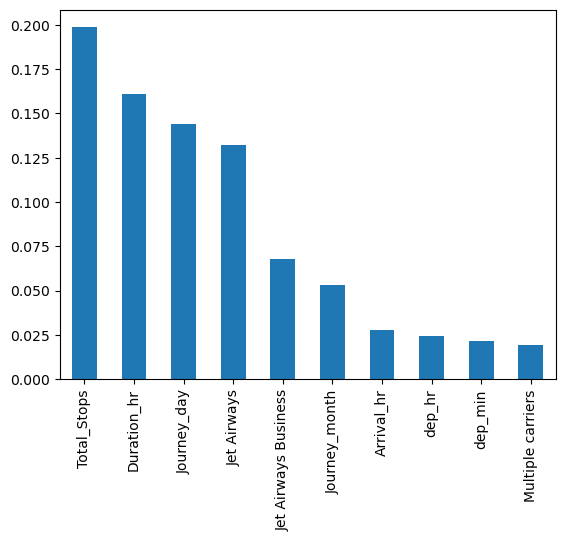

In [75]:
a.nlargest(10).plot(kind="bar")

## Now try all models in one loop

In [76]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR

In [77]:
model = [DecisionTreeRegressor,KNeighborsRegressor,RandomForestRegressor,AdaBoostRegressor,SVR]

for i in model:
    reg = i()
    reg = reg.fit(x_train,y_train)
    print(i,"accuracy",reg.score(x_test,y_test))

<class 'sklearn.tree._classes.DecisionTreeRegressor'> accuracy 0.7024525181303349
<class 'sklearn.neighbors._regression.KNeighborsRegressor'> accuracy 0.5749800770668477
<class 'sklearn.ensemble._forest.RandomForestRegressor'> accuracy 0.8033155204039517
<class 'sklearn.ensemble._weight_boosting.AdaBoostRegressor'> accuracy 0.39431489080366233
<class 'sklearn.svm._classes.SVR'> accuracy 0.004675687532239681


### Model Performance Validation

In [78]:
from sklearn.model_selection import KFold,cross_val_score

In [79]:
models = []
models.append(('KNN',KNeighborsRegressor()))
models.append(('CART',DecisionTreeRegressor()))
models.append(('RF',RandomForestRegressor()))
models.append(('SVM',SVR()))
models.append(('AdaBoost',AdaBoostRegressor()))

results = []
names = []

for name,model in models:
    kfold = KFold(n_splits=10)
    cv_result = cross_val_score(model,x_train,y_train,cv=kfold)
    names.append(name)
    results.append(cv_result)

In [80]:
for i in range(len(names)):
    print(names[i],results[i].mean())

KNN 0.5467748024866249
CART 0.6860916155091668
RF 0.8033700063033358
SVM -0.0038952547945292682
AdaBoost 0.38998250058560424


In [81]:
print(results)

[array([0.55374751, 0.55821717, 0.52911064, 0.54399479, 0.5626081 ,
       0.60183249, 0.51768131, 0.53681089, 0.54371775, 0.52002738]), array([0.64619189, 0.674955  , 0.60821632, 0.69171534, 0.76202922,
       0.69103314, 0.65011877, 0.75418998, 0.66831755, 0.71414896]), array([0.81077612, 0.81187104, 0.8211597 , 0.76977555, 0.83068467,
       0.83353264, 0.74078897, 0.8321107 , 0.78718986, 0.79581082]), array([ 0.0074534 ,  0.02393912, -0.01018205, -0.00904338, -0.00947174,
       -0.02626183,  0.01327206, -0.01246101,  0.00081325, -0.01701037]), array([0.29376465, 0.24563424, 0.49369923, 0.2826873 , 0.57303199,
       0.39918347, 0.30528986, 0.39625936, 0.51932382, 0.39095109])]


## Now Final Apply Random Forest Algorithm

In [82]:
from sklearn.ensemble import RandomForestRegressor

In [83]:
model = RandomForestRegressor()

In [84]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [85]:
model.score(x_train,y_train)

0.9556909711737497

In [86]:
model.score(x_test,y_test)

0.8038427140783998